In [ ]:
import pandas as pd

df = pd.read_csv('data/temp/merged_final_data.csv')

In [2]:
df.columns

Index(['iso_code', 'Year', 'Unnamed..0', 'doc_id', 'text', 'final_label',
       'matched_keywords', 'num_matched_sentences', 'sentence_id',
       'r1_reasoning', 'ieo_sentiment', 'Entity', 'trade_balance',
       'wb_region'],
      dtype='str')

In [2]:
df['r1_reasoning'].iloc[0]

'Okay, so I need to analyze the sentiment of the given UN speech text towards the "International Economic Order" (IEO). The text is: "World trade is an important instrument of co-operation among nations." \r\n\r\nFirst, I should recall the sentiment categories provided. Positive sentiment includes satisfaction with globalization, multilateralism, and support for institutions like the WTO, IMF, and World Bank. It also involves the belief that the current system benefits all. Negative sentiment, on the other hand, involves grievances about inequality, unfair trade, debt, economic imperialism, or calls for reform because the system is seen as unjust.\r\n\r\nLooking at the text, it states that world trade is an "important instrument of co-operation among nations." The key words here are "important" and "co-operation." These suggest that the speaker views world trade positively, as a tool that helps nations work together. The phrase "instrument of co-operation" implies that trade facilitate

In [3]:
df['r1_reasoning'].iloc[1]

'Okay, so I need to analyze the sentiment of this UN speech text regarding the International Economic Order. The text is: "This co-operation will be strengthened if discriminatory economic and trade policies are not pursued by one or a group of nations against other nations."\r\n\r\nFirst, I should break down the key elements. The sentence talks about cooperation being strengthened. That\'s a positive note because it implies that working together is beneficial. However, it\'s conditional on not pursuing discriminatory policies.\r\n\r\nDiscriminatory policies are a negative aspect because they suggest unfair treatment, which can lead to inequality or harm in international relations. The speaker is pointing out that avoiding such policies would be good for cooperation, which means they are critical of those policies.\r\n\r\nLooking at the sentiment categories, Positive is about satisfaction with globalization and multilateralism, while Negative is about grievances like unfair trade terms

In [4]:
df['r1_reasoning'].iloc[2]

'Alright, I need to analyze the sentiment of the given UN speech text towards the International Economic Order (IEO). The categories are Positive and Negative, so I\'ll focus on whether the text expresses satisfaction or dissatisfaction.\r\n\r\nThe text says: "recognize the importance of international trade, and we have maintained our trade relations in an atmosphere of friendly co-operation with all countries."\r\n\r\nFirst, I notice the use of positive verbs like "recognize" and "maintained," which indicate approval and continuity. The phrase "friendly co-operation" suggests a harmonious and positive interaction with other countries in trade relations.\r\n\r\nThe text emphasizes international trade\'s importance and the ongoing friendly cooperation, which aligns with the Positive category. It doesn\'t mention any grievances or structural issues, so it doesn\'t fall into the Negative category.\r\n\r\nTherefore, the sentiment is Positive because it shows satisfaction with the current i

In [3]:
df['wb_region'].unique()

<ArrowStringArray>
[                                                  nan,
                                  'Sub-Saharan Africa',
                             'Europe and Central Asia',
 'Middle East, North Africa, Afghanistan and Pakistan',
                     'Latin America and the Caribbean',
                               'East Asia and Pacific',
                                          'South Asia',
                                       'North America']
Length: 8, dtype: str

C:\Users\user\AppData\Local\Temp\ipykernel_18728\2072383568.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='wb_region', palette='viridis', order=df['wb_region'].value_counts().index)


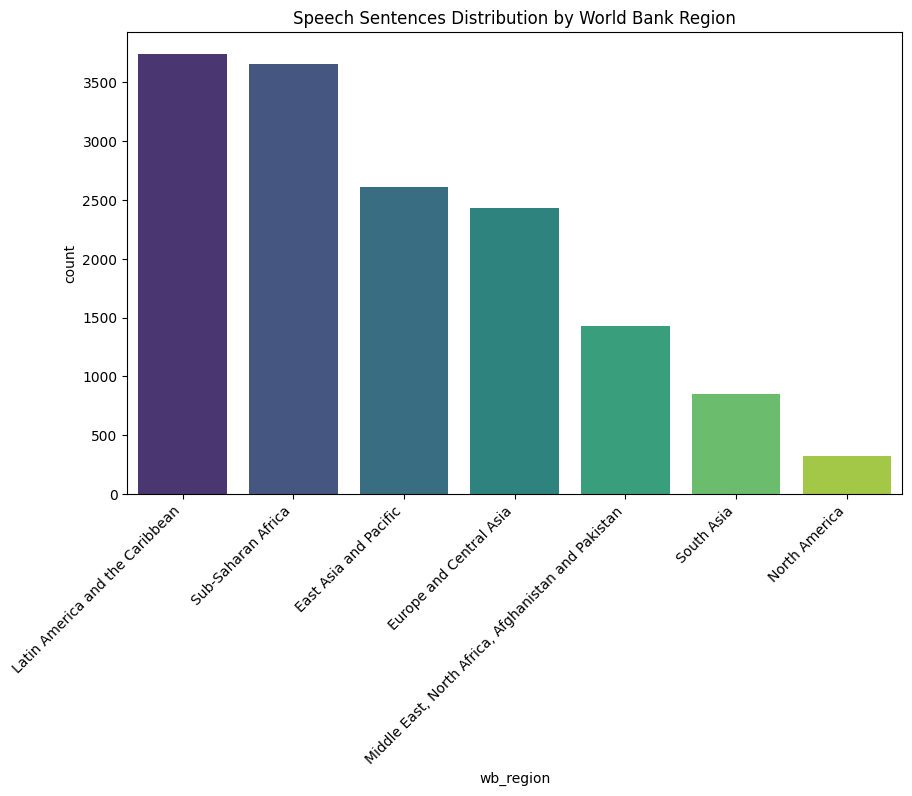

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
# 'palette' automatically gives each region a different color
sns.countplot(data=df, x='wb_region', palette='viridis', order=df['wb_region'].value_counts().index)

plt.xticks(rotation=45, ha='right')
plt.title('Speech Sentences Distribution by World Bank Region')
plt.show()

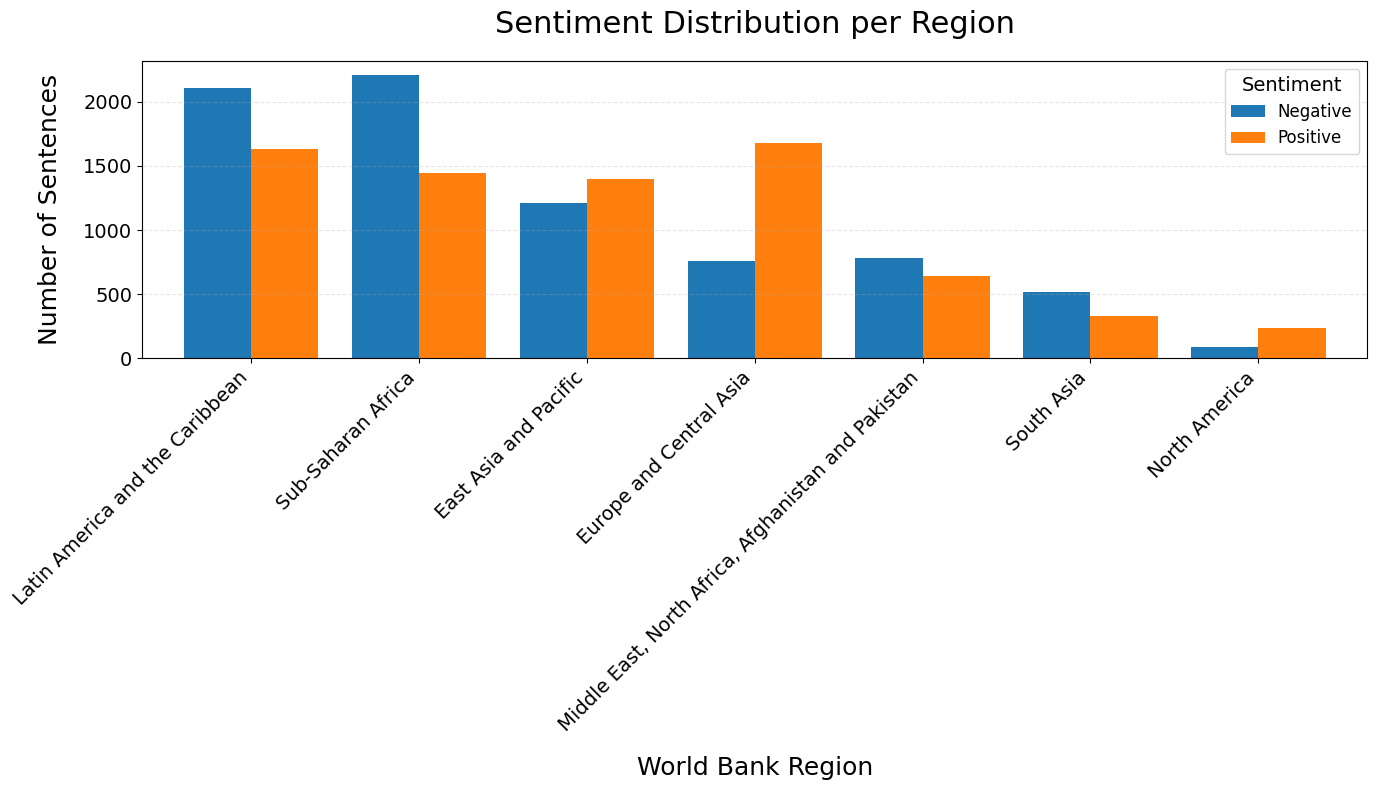

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Create a pivot table
sentiment_split = df.groupby(['wb_region', 'ieo_sentiment']).size().unstack(fill_value=0)

# 2. Sort by total count
sentiment_split['total'] = sentiment_split.sum(axis=1)
sentiment_split = sentiment_split.sort_values('total', ascending=False).drop(columns='total')

# 3. Plot
ax = sentiment_split.plot(kind='bar', figsize=(14, 8), width=0.8)

# 4. Formatting
plt.title('Sentiment Distribution per Region', fontsize=22, pad=20)

# FIX: Changed 'frontsize' to 'fontsize' and increased sizes
plt.xlabel('World Bank Region', fontsize=18, labelpad=15)
plt.ylabel('Number of Sentences', fontsize=18, labelpad=15)

# FIX: Changed 'frontsize' to 'fontsize' here as well
plt.xticks(rotation=45, ha='right', fontsize=14) 
plt.yticks(fontsize=14)

plt.legend(title='Sentiment', fontsize=12, title_fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('region_sentiment_grouped.png')
plt.show()